Step 0: Import config


In [1]:
from config import config as cf

Step 1: Load dataset

In [2]:
dataset = cf.pd.read_csv(cf.basic_dataset, sep=cf.separator)
print(dataset.dtypes)

Date                                                                             str
Service                                                                          str
Departure station                                                                str
Arrival station                                                                  str
Average journey time                                                             str
Number of scheduled trains                                                       str
Number of cancelled trains                                                       str
Cancellation comments                                                            str
Number of trains delayed at departure                                            str
Average delay of late trains at departure                                        str
Average delay of all trains at departure                                         str
Departure delay comments                                         

Step 3: Convert type of date to datetime

In [3]:
dataset[cf.date] = cf.pd.to_datetime(dataset[cf.date], format="%Y-%m", errors="coerce").dt.date
dataset.dropna(subset=[cf.date], inplace=True)
dataset[cf.date] = cf.pd.to_datetime(dataset[cf.date])
print(dataset.dtypes)

Date                                                                             datetime64[s]
Service                                                                                    str
Departure station                                                                          str
Arrival station                                                                            str
Average journey time                                                                       str
Number of scheduled trains                                                                 str
Number of cancelled trains                                                                 str
Cancellation comments                                                                      str
Number of trains delayed at departure                                                      str
Average delay of late trains at departure                                                  str
Average delay of all trains at departure          

Step 4: Convert columns types in numeric when necessary

In [4]:
dataset[cf.average_journey_time] = cf.pd.to_numeric(dataset[cf.average_journey_time], errors="coerce")
dataset[cf.number_train_sheduled] = cf.pd.to_numeric(dataset[cf.number_train_sheduled], errors="coerce")
dataset[cf.number_train_cancel] = cf.pd.to_numeric(dataset[cf.number_train_cancel], errors="coerce")
dataset[cf.number_train_delayed_departure] = cf.pd.to_numeric(dataset[cf.number_train_delayed_departure], errors="coerce")
dataset[cf.average_delay_late_train_at_departure] = cf.pd.to_numeric(dataset[cf.average_delay_late_train_at_departure], errors="coerce")
dataset[cf.average_delay_all_at_departure] = cf.pd.to_numeric(dataset[cf.average_delay_all_at_departure], errors="coerce")
dataset[cf.number_train_delayed_arrival] = cf.pd.to_numeric(dataset[cf.number_train_delayed_arrival], errors="coerce")
dataset[cf.average_delay_late_train_at_arrival] = cf.pd.to_numeric(dataset[cf.average_delay_late_train_at_arrival], errors="coerce")
dataset[cf.average_delay_all_train_at_arrival] = cf.pd.to_numeric(dataset[cf.average_delay_all_train_at_arrival], errors="coerce")
dataset[cf.number_train_delay_sup_15min] = cf.pd.to_numeric(dataset[cf.number_train_delay_sup_15min], errors="coerce")
dataset[cf.average_delay_sup_15min_competing_flight] = cf.pd.to_numeric(dataset[cf.average_delay_sup_15min_competing_flight], errors="coerce")
dataset[cf.number_train_delay_sup_30min] = cf.pd.to_numeric(dataset[cf.number_train_delay_sup_30min], errors="coerce")
dataset[cf.number_train_delay_sup_60min] = cf.pd.to_numeric(dataset[cf.number_train_delay_sup_60min], errors="coerce")
dataset[cf.pct_delay_external_cause] = cf.pd.to_numeric(dataset[cf.pct_delay_external_cause], errors="coerce")
dataset[cf.pct_delay_infrastructure] = cf.pd.to_numeric(dataset[cf.pct_delay_infrastructure], errors="coerce")
dataset[cf.pct_delay_traffic] = cf.pd.to_numeric(dataset[cf.pct_delay_traffic], errors="coerce")
dataset[cf.pct_rolling_stock] = cf.pd.to_numeric(dataset[cf.pct_rolling_stock], errors="coerce")
dataset[cf.pct_delay_traffic] = cf.pd.to_numeric(dataset[cf.pct_delay_traffic], errors="coerce")
dataset[cf.pct_equipement_station_management] = cf.pd.to_numeric(dataset[cf.pct_equipement_station_management], errors="coerce")
dataset[cf.pct_passenger] = cf.pd.to_numeric(dataset[cf.pct_passenger], errors="coerce")

print(dataset.dtypes)

Date                                                                             datetime64[s]
Service                                                                                    str
Departure station                                                                          str
Arrival station                                                                            str
Average journey time                                                                   float64
Number of scheduled trains                                                             float64
Number of cancelled trains                                                             float64
Cancellation comments                                                                      str
Number of trains delayed at departure                                                  float64
Average delay of late trains at departure                                              float64
Average delay of all trains at departure          

Step 6: Add new feature columns

In [5]:
dataset[cf.year] = dataset[cf.date].dt.year
dataset[cf.month] = dataset[cf.date].dt.month_name()

def get_delay_category(delay):
    if (delay < 15):
        return "Minimum delay"
    if (delay < 30):
        return "Low delay"
    if (delay < 60):
        return "Medium delay"
    return "Significant delay"

def is_go_to_Paris(arrival):
    return "PARIS" in str(arrival)

dataset[cf.delay_category] = dataset[cf.average_delay_all_train_at_arrival].apply(get_delay_category)
dataset[cf.rate_cancel_train] =  (dataset[cf.number_train_cancel] / dataset[cf.number_train_sheduled].replace(0, float('nan'))) * 100
dataset[cf.rate_delay_train] =  (dataset[cf.number_train_delayed_arrival] / dataset[cf.number_train_sheduled].replace(0, float('nan'))) * 100
dataset[cf.go_to_Paris] = dataset[cf.arrival].apply(is_go_to_Paris)
dataset.to_csv('data/cleaned_dataset.csv', index=False)
print(dataset.loc[dataset[cf.rate_delay_train].idxmax()])

Date                                                                             2019-09-01 00:00:00
Service                                                                                     National
Departure station                                                                   BORDEAUX ST JEAN
Arrival station                                                                            TOURCOING
Average journey time                                                                           301.0
Number of scheduled trains                                                                      20.0
Number of cancelled trains                                                                       0.0
Cancellation comments                                                                            NaN
Number of trains delayed at departure                                                           10.0
Average delay of late trains at departure                                                  

Step 7 : data analysis and comprehension

In [6]:
display(dataset.describe())

,Date,Average journey time,Number of scheduled trains,Number of cancelled trains,Number of trains delayed at departure,Average delay of late trains at departure,Average delay of all trains at departure,Number of trains delayed at arrival,Average delay of late trains at arrival,Average delay of all trains at arrival,...,Number of trains delayed > 60min,Pct delay due to external causes,Pct delay due to infrastructure,Pct delay due to traffic management,Pct delay due to rolling stock,Pct delay due to station management and equipment reuse,"Pct delay due to passenger handling (crowding, disabled persons, connections)",Year,Rate Cancel train,Rate delay train
count,11684,11324.000000,11426.000000,11424.000000,11439.000000,11338.000000,11337.000000,11428.000000,11335.000000,11327.000000,...,11425.000000,11336.000000,11348.000000,11341.000000,11344.000000,11321.000000,11336.000000,11684.000000,11106.000000,11103.000000
mean,2021-12-06 08:41:56,170.813363,270.535095,8.676646,87.075881,12.292656,3.129173,37.319828,35.197624,6.096186,...,5.150372,21.546327,21.838651,20.385833,18.881869,7.380673,7.592111,2021.472869,3.887014,13.884310
min,2018-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,-229.269444,0.000000,-40.109259,-173.076970,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2018.000000,0.000000,0.000000
25%,2019-12-01 00:00:00,100.000000,150.000000,0.000000,21.000000,6.144041,1.207491,15.000000,25.759204,3.401846,...,1.000000,10.526316,11.873422,10.344828,10.000000,0.000000,0.000000,2019.000000,0.000000,8.771930
50%,2021-12-01 00:00:00,163.000000,229.000000,2.000000,52.000000,10.350777,2.328475,29.000000,33.481313,5.356601,...,3.000000,19.148936,20.000000,18.750000,17.073171,5.882353,5.000000,2021.000000,0.691045,12.601626
75%,2023-12-01 00:00:00,223.000000,358.000000,7.000000,127.000000,15.775275,3.957895,51.000000,42.479497,8.101078,...,7.000000,30.000000,29.629630,28.571429,25.423729,11.111111,11.111111,2023.000000,3.100775,17.391304
max,2025-12-01 00:00:00,703.130000,1100.000000,288.000000,1066.000000,316.188000,115.047390,376.000000,299.600000,92.000000,...,71.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,2025.000000,92.682927,100.000000
std,NaN,87.974472,182.445699,22.561270,91.049993,11.874615,5.141283,31.150872,15.728582,5.501205,...,5.976697,15.947538,14.911383,14.697649,13.508094,8.064904,9.499027,2.308494,8.683025,7.650073


Step 8 : Do a graph to show average delay value

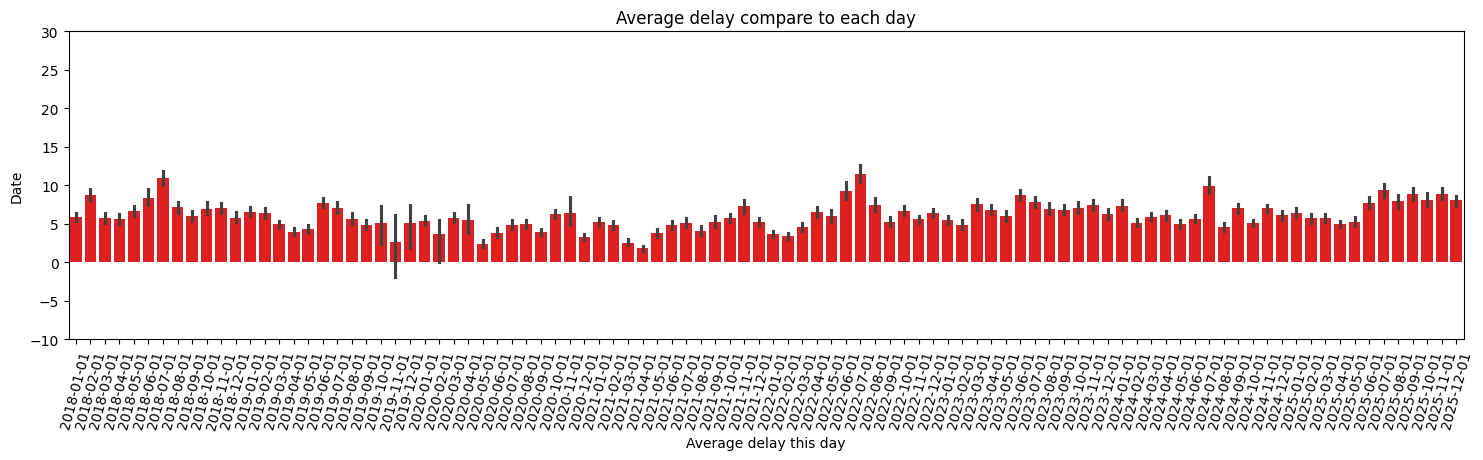

In [7]:
import matplotlib.pyplot as plot
import seaborn as sns

plot.figure(figsize=(18, 4))
sns.barplot(x=dataset[cf.date], y=dataset[cf.average_delay_all_train_at_arrival], color='red')
plot.title('Average delay compare to each day')
plot.ylim(-10, 30)
plot.xlabel('Average delay this day')
plot.ylabel('Date')
plot.xticks(rotation=75)
plot.show()

This graph shows that the delays are not correlated with the different years. However, we can see that the time of year may play a role.

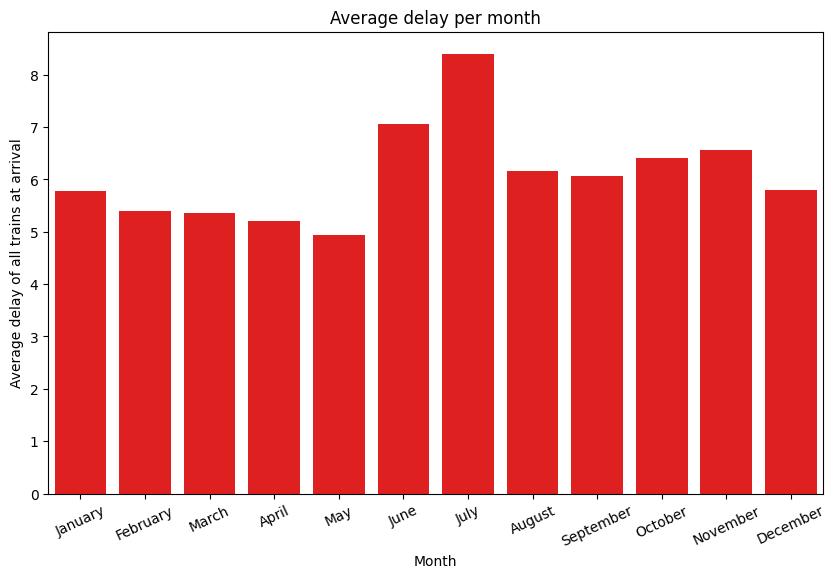

In [8]:
plot.figure(figsize=(10, 6))
sns.barplot(data=dataset, x=cf.month, y=cf
            .average_delay_all_train_at_arrival, errorbar=None, color='red')
plot.title('Average delay per month')
plot.xticks(rotation=25)
plot.show()

This graph confirms the hypothesis of the previous graph. Indeed, we see here that summer periods are more likely to cause delays. However, we can also wonder if this cause is the influx of travelers rather than simply the season.

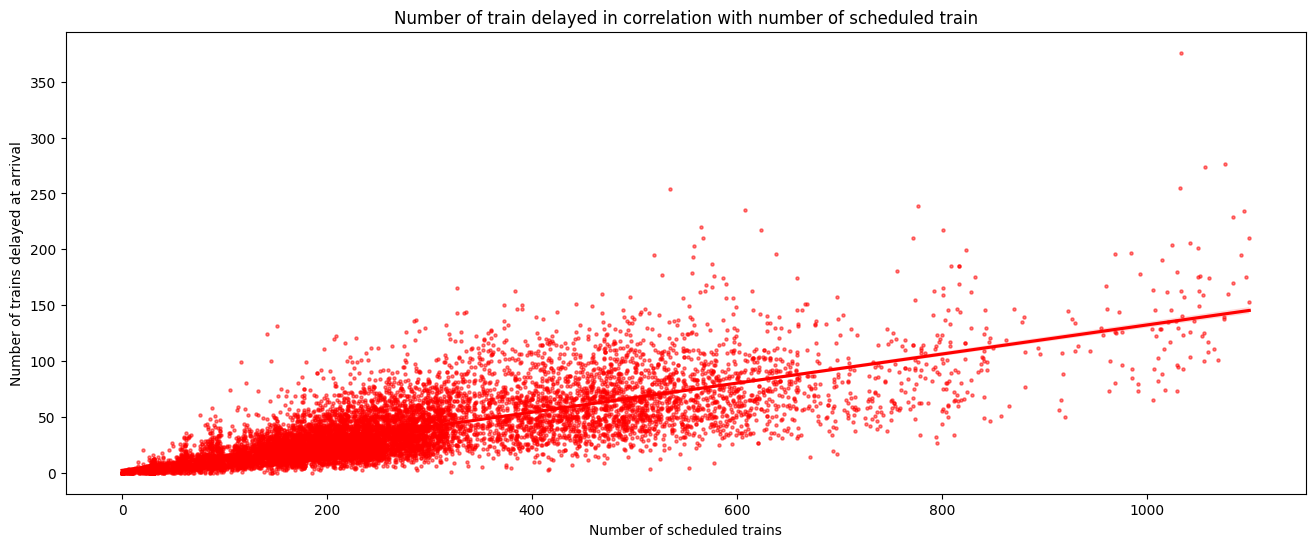

In [10]:
plot.figure(figsize=(16, 6))
sns.regplot(data=dataset,
            x=cf.number_train_sheduled,
            y=cf.number_train_delayed_arrival,
            color="red",
            scatter_kws={'s': 5, 'alpha': 0.5})
plot.title('Number of train delayed in correlation with number of scheduled '
           'train')
plot.show()

On this linear regression line, we see that the number of scheduled train
follow the number of train delayed. So the more trains there are in service, the more delays there are.

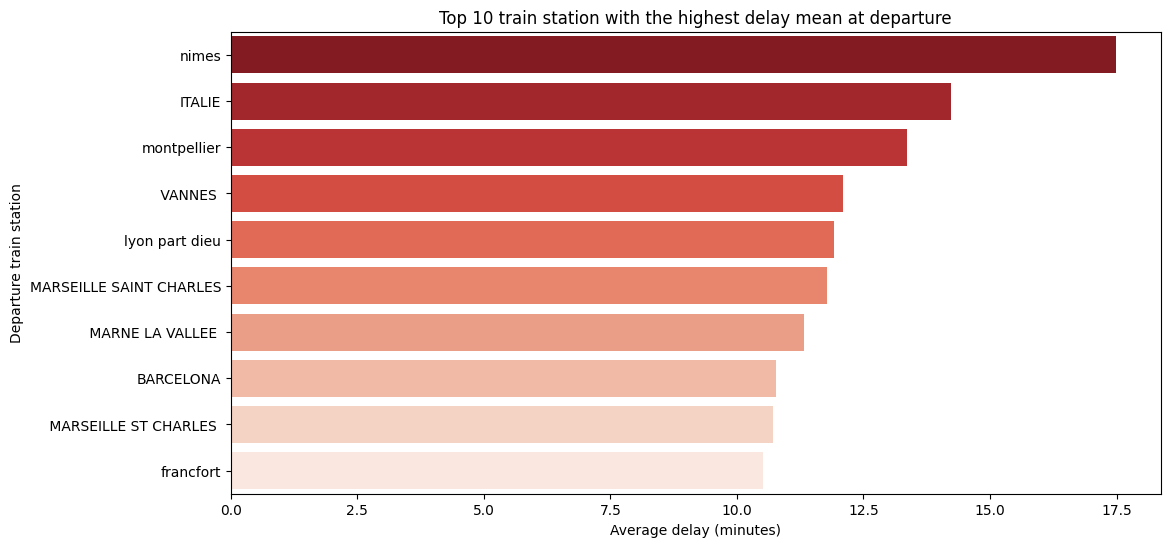

In [9]:
plot.figure(figsize=(12, 6))

worst_ts = dataset.groupby(cf.departure)[cf.average_delay_all_train_at_arrival].mean().sort_values(ascending=False).head(10)
sns.barplot(x=worst_ts.values, y=worst_ts.index, hue=worst_ts.index,
            palette='Reds_r')
plot.title('Top 10 train station with the highest delay mean at departure')
plot.xlabel('Average delay (minutes)')
plot.ylabel('Departure train station')
plot.show()

We see that Nimes Station is the worst train station with 17.5 average
minutes of delay. So the most able to create delay. In departure and not at
arrival to see if train station is really in cause.

## Conclusion

In conclusion, we can see that the link between the number of trains in service and the number of delays is well established. However, we also see that the number of trains in service increases at certain times of the year, and therefore, the number of delays also increases. We have also seen that the station can play a significant role, as several stations in Europe are responsible for the observed delays.